# Sound-Based Spin Estimation in Table Tennis
## Part 2: Bounce Sound Classification

This notebook evaluates pre-trained **CNN classifiers** on the bounce sound dataset for two tasks:
1. **Surface classification** (13 classes: 10 rackets + table + floor + other)
2. **Spin classification** (3 classes: backspin, no-spin, topspin)

### Outline

1. **Data Loading** — loading train/test splits and inspecting the Mel spectrogram input
2. **Surface Classification** — loading the pre-trained surface model and evaluating on the test set
3. **Spin Classification** — loading the pre-trained spin model and evaluating on the test set

In [1]:
import sys
sys.path.insert(0, '..')

import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import lightning as lightning
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report

from dataset import SoundDS, SURFACE_CLASSES, SPIN_CLASSES,SoundDataModule
from classifier.cnn import AudioClassifier
import plots

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.facecolor'] = 'white'
plt.style.use("dark_background")

DATA_DIR = '../data'
MODEL_DIR = '../models'
SOUNDS_DIR = f'{DATA_DIR}/sounds'
lightning.seed_everything(42)

Seed set to 42


42

---
## 1. Data Loading

We load the pre-split train and test CSVs and wrap them in `SoundDS` datasets. Each sample yields a Mel spectrogram tensor, a surface label, and a spin label. Training data uses augmentation; test data does not.

In [2]:
# Load datasets
train_ds = SoundDS(f'{DATA_DIR}/train.csv', SOUNDS_DIR, augment=True)
test_ds = SoundDS(f'{DATA_DIR}/test.csv', SOUNDS_DIR, augment=False)

# Data loaders
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=4)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=4)

print(f"Training samples: {len(train_ds)}")
print(f"Test samples:     {len(test_ds)}")

# Check a sample
mel, surface, spin = train_ds[0]
print(f"\nMel spectrogram shape: {mel.shape}")
print(f"Surface label: {surface.item()} ({SURFACE_CLASSES[surface.item()]})")
print(f"Spin label:    {spin.item()} ({SPIN_CLASSES[spin.item()]})")

Training samples: 4561
Test samples:     1141

Mel spectrogram shape: torch.Size([1, 64, 10])
Surface label: 10 (racket_10)
Spin label:    1 (none)


The Mel spectrogram shape shows the input dimensions the CNN expects. Each bounce clip is converted into a fixed-size spectrogram that serves as the single input channel to the network.

---
## 2. Surface Classification — Evaluation

We load the pre-trained surface classifier from a checkpoint and evaluate it on the held-out test set. The model was trained to distinguish 13 surface classes (10 racket types + table + floor + other).

We report per-class precision, recall, and F1, along with a confusion matrix to visualize where the model confuses surfaces.

In [3]:
# Surface classifier
surface_model = AudioClassifier.load_from_checkpoint(os.path.join(MODEL_DIR, 'surface_best.ckpt'))
print(surface_model)
print(f"\nNumber of parameters: {sum(p.numel() for p in surface_model.parameters()):,}")

AudioClassifier(
  (features): Sequential(
    (0): Conv2d(1, 2, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (1): ReLU()
    (2): BatchNorm2d(2, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Conv2d(2, 4, kernel_size=(3, 3), stride=(2, 1), padding=(1, 1))
    (4): ReLU()
    (5): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): Conv2d(4, 8, kernel_size=(3, 3), stride=(2, 1), padding=(1, 1))
    (7): ReLU()
    (8): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 1), padding=(1, 1))
    (10): ReLU()
    (11): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 1), padding=(1, 1))
    (13): ReLU()
    (14): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (15): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 1), pa

Surface Classification Report:
              precision    recall  f1-score   support

       other       0.98      1.00      0.99       248
   racket_01       0.93      0.94      0.94       179
   racket_02       0.88      0.95      0.91        60
   racket_03       0.83      0.78      0.80        55
   racket_04       0.90      0.81      0.85        58
   racket_05       0.95      0.81      0.88        48
   racket_06       0.82      0.98      0.89        41
   racket_07       0.89      0.84      0.86        49
   racket_08       0.99      0.99      0.99        67
   racket_09       0.89      0.92      0.90        59
   racket_10       0.94      0.92      0.93        64
       table       0.99      0.97      0.98       155
       floor       0.98      1.00      0.99        58

    accuracy                           0.94      1141
   macro avg       0.92      0.92      0.92      1141
weighted avg       0.94      0.94      0.94      1141



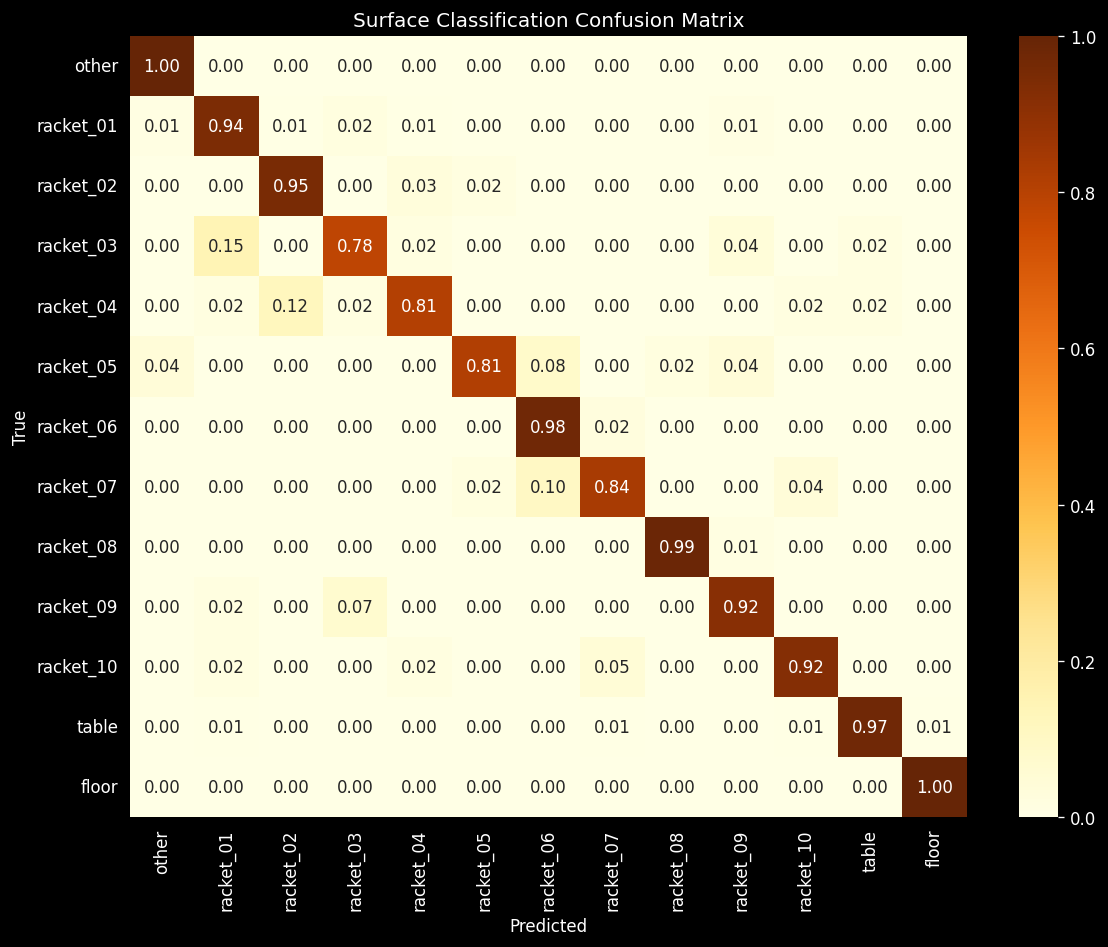

In [4]:
# Evaluate surface classifier
device = next(surface_model.parameters()).device
surface_model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for mel, surface, spin in test_loader:
        mel = mel.to(device)
        logits = surface_model(mel)
        preds = logits.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(surface.cpu().numpy())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

print("Surface Classification Report:")
# Only show classes that appear in the data
present = sorted(set(all_targets) | set(all_preds))
print(classification_report(all_targets, all_preds,
                           labels=present,
                           target_names=[SURFACE_CLASSES[i] for i in present]))

fig = plots.plot_confusion_matrix(all_targets, all_preds,
                           class_names=[SURFACE_CLASSES[i] for i in present],
                           title='Surface Classification Confusion Matrix')
plt.show()

The classification report shows per-class metrics and the confusion matrix highlights which surfaces are most often confused with each other. Racket types with similar rubber properties are expected to be harder to distinguish than structurally different surfaces (e.g., table vs. floor).

---
## 3. Spin Classification — Evaluation

We load the pre-trained spin classifier and evaluate it on the same test set. This model classifies each bounce into one of three spin directions: backspin, no-spin, or topspin.

As noted in Notebook 01, spin direction is harder to distinguish acoustically than spin presence. The confusion matrix will show whether the model struggles more with back-vs-top confusion or with spin-vs-no-spin separation.

In [5]:
# Spin classifier
spin_model = AudioClassifier.load_from_checkpoint(os.path.join(MODEL_DIR, 'spin_best.ckpt'),strict=False)
print(spin_model)
print(f"\nNumber of parameters: {sum(p.numel() for p in spin_model.parameters()):,}")

AudioClassifier(
  (features): Sequential(
    (0): Conv2d(1, 2, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (1): ReLU()
    (2): BatchNorm2d(2, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Conv2d(2, 4, kernel_size=(3, 3), stride=(2, 1), padding=(1, 1))
    (4): ReLU()
    (5): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): Conv2d(4, 8, kernel_size=(3, 3), stride=(2, 1), padding=(1, 1))
    (7): ReLU()
    (8): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 1), padding=(1, 1))
    (10): ReLU()
    (11): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 1), padding=(1, 1))
    (13): ReLU()
    (14): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (15): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 1), pa

Spin Classification Report:
              precision    recall  f1-score   support

        back       0.90      0.89      0.90       230
        none       0.99      0.97      0.98       776
         top       0.83      0.93      0.88       135

    accuracy                           0.95      1141
   macro avg       0.91      0.93      0.92      1141
weighted avg       0.95      0.95      0.95      1141



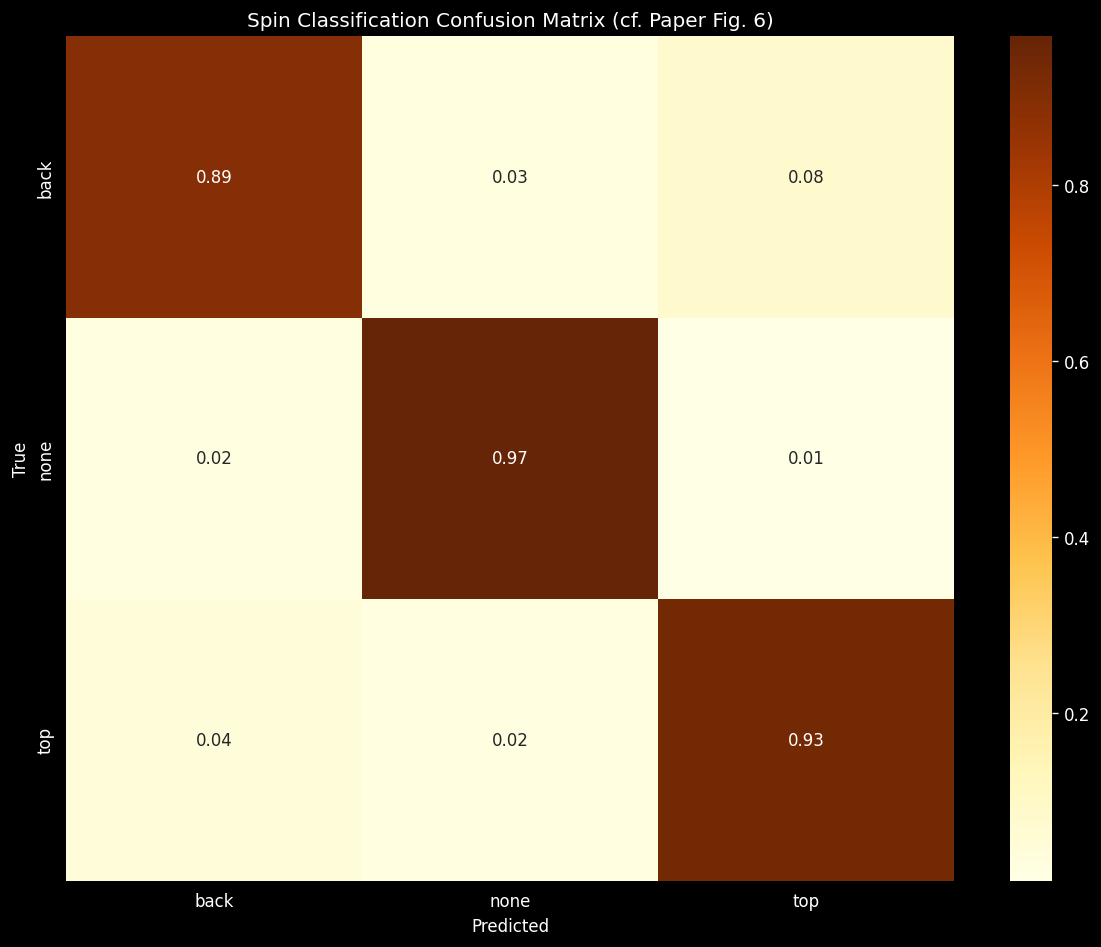

In [6]:
# Evaluate spin classifier
device = next(spin_model.parameters()).device
spin_model.eval()
all_preds_spin = []
all_targets_spin = []

with torch.no_grad():
    for mel, surface, spin in test_loader:
        mel = mel.to(device)
        logits = spin_model(mel)
        preds = logits.argmax(dim=1)
        all_preds_spin.extend(preds.cpu().numpy())
        all_targets_spin.extend(spin.cpu().numpy())

all_preds_spin = np.array(all_preds_spin)
all_targets_spin = np.array(all_targets_spin)

print("Spin Classification Report:")
print(classification_report(all_targets_spin, all_preds_spin,
                           target_names=SPIN_CLASSES))

fig = plots.plot_confusion_matrix(all_targets_spin, all_preds_spin,
                           class_names=SPIN_CLASSES,
                           title='Spin Classification Confusion Matrix (cf. Paper Fig. 6)')
plt.show()

The spin classification report and confusion matrix above show the model's ability to distinguish spin directions from Mel spectrograms alone.

---
## 4. Conclusion

This notebook evaluated two pre-trained CNN classifiers on the bounce sound test set:

- **Surface classification** distinguishes 13 surface types from 15 ms Mel spectrograms. The confusion matrix reveals which racket types are acoustically similar and where the model's errors concentrate.
- **Spin classification** tackles the harder problem of distinguishing backspin, topspin, and no-spin from sound alone. As expected from the spectral analysis in Notebook 01, spin presence is easier to detect than spin direction.

These results confirm that short bounce sounds contain enough discriminative information for both tasks, validating the signal processing pipeline developed in Notebook 01.